In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
from pyspark.sql import SparkSession
from IPython.display import display
import ipywidgets as widgets
from collections import Counter
from datetime import timedelta
import re
import plotly.graph_objects as go

from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
username = "skowalski"

In [4]:
file_path = "/content/gdrive/MyDrive/Colab Notebooks/UPenn/dataset/Analysis_Updated/PatientUSER-"+username+".xlsx"  # your file path
df = pd.read_excel(file_path)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [5]:
# DPS（Days Post Surgery）
def extract_dps(operation_str):
    match = re.search(r'(Pre|Post)\s*Op\s*DAY\s*(\d+)', operation_str, re.IGNORECASE)
    if match:
        day = int(match.group(2))
        return -day if 'Pre' in match.group(1) else day
    return None

df['DPS'] = df['Operation'].apply(extract_dps)

pre_days = abs(df[df['DPS'] < 0]['DPS'].min()) if (df['DPS'] < 0).any() else 0
post_days = df[df['DPS'] > 0]['DPS'].max() if (df['DPS'] > 0).any() else 0

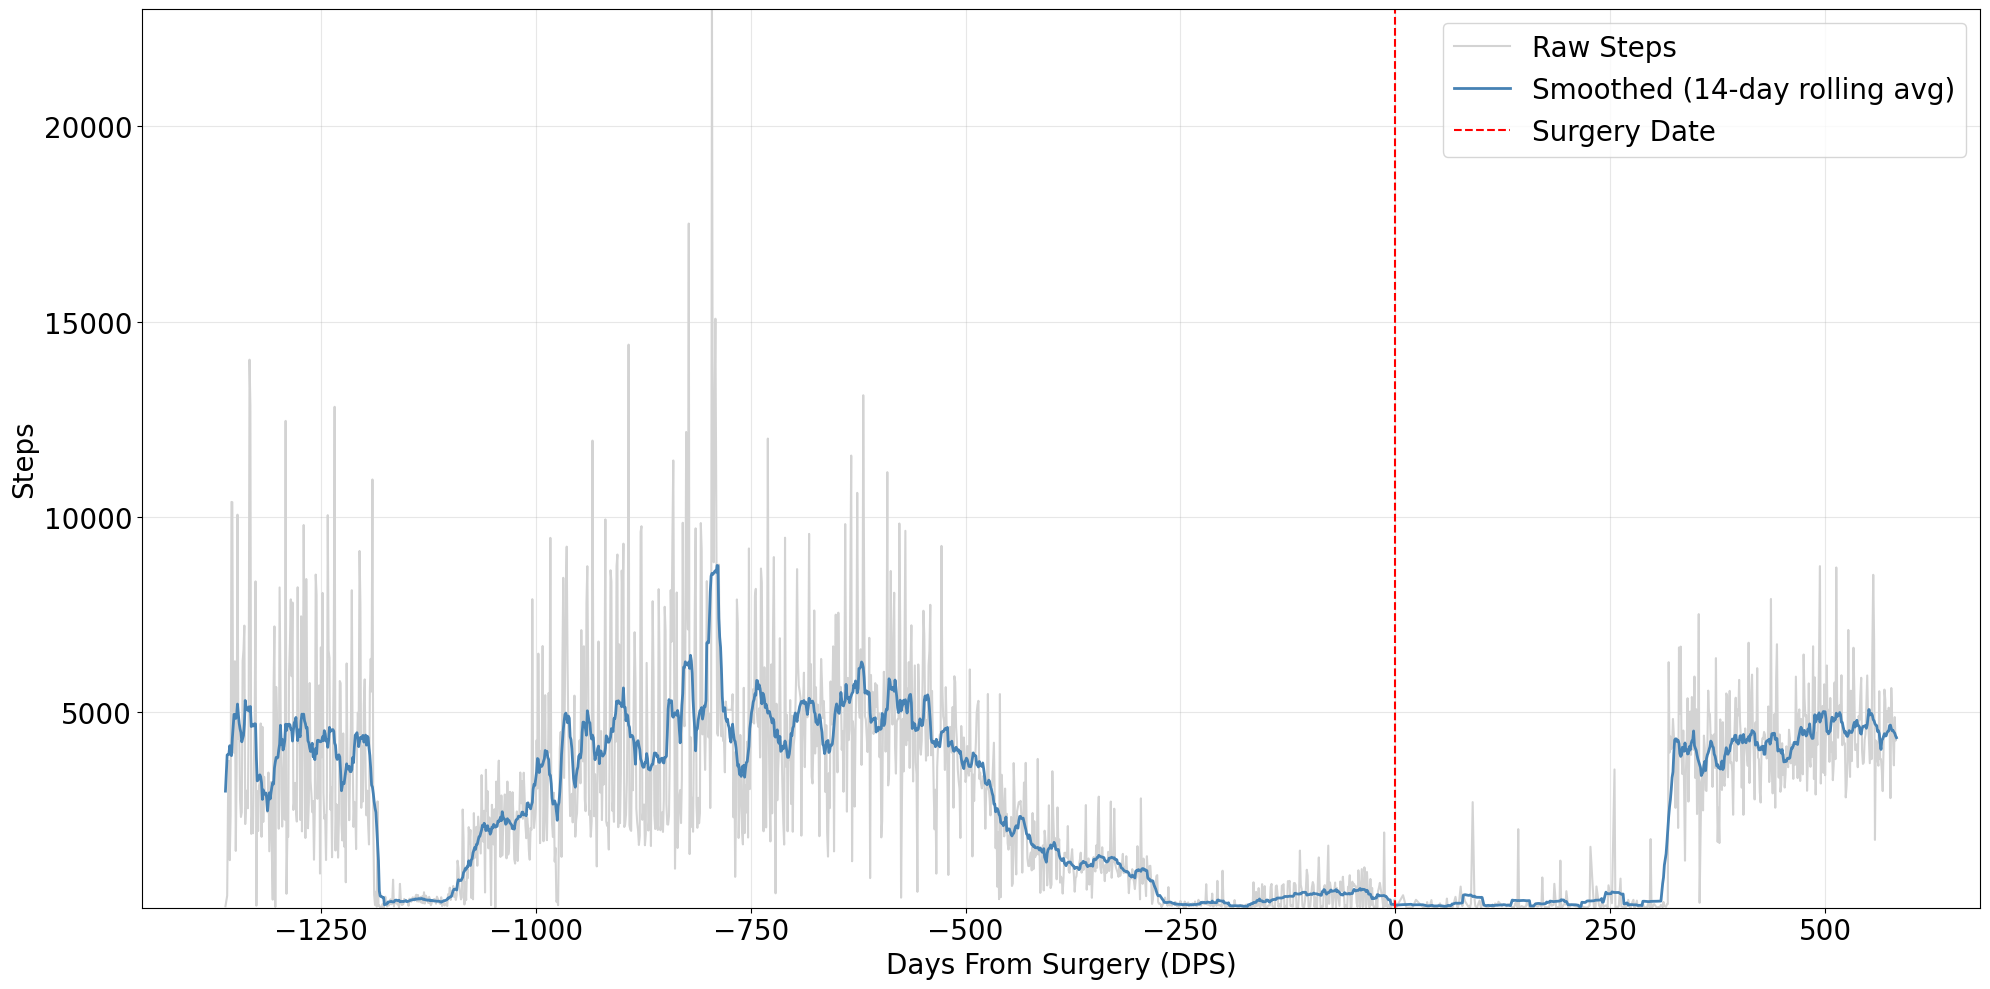

In [6]:
window_days = 14
df['Smoothed_Steps'] = df['Steps'].rolling(window=window_days, min_periods=1, center=True).mean()

plt.figure(figsize=(20, 10))
plt.plot(df['DPS'], df['Steps'], color='lightgray', linewidth=1.5, label='Raw Steps')
plt.plot(df['DPS'], df['Smoothed_Steps'], color='steelblue', linewidth=2, label='Smoothed (14-day rolling avg)')

plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Surgery Date')
#plt.title(
#    f"Patient-({username})\nPre-op: {int(pre_days)} days pre-op, Post-op: {int(post_days)} days post-op",
#    fontsize=13, pad=15
#)

y_min = df['Steps'].min()
y_max = df['Steps'].max()
plt.ylim(y_min, y_max)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.xlabel("Days From Surgery (DPS)", fontsize=20)
plt.ylabel("Steps", fontsize=20)
plt.legend(fontsize=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


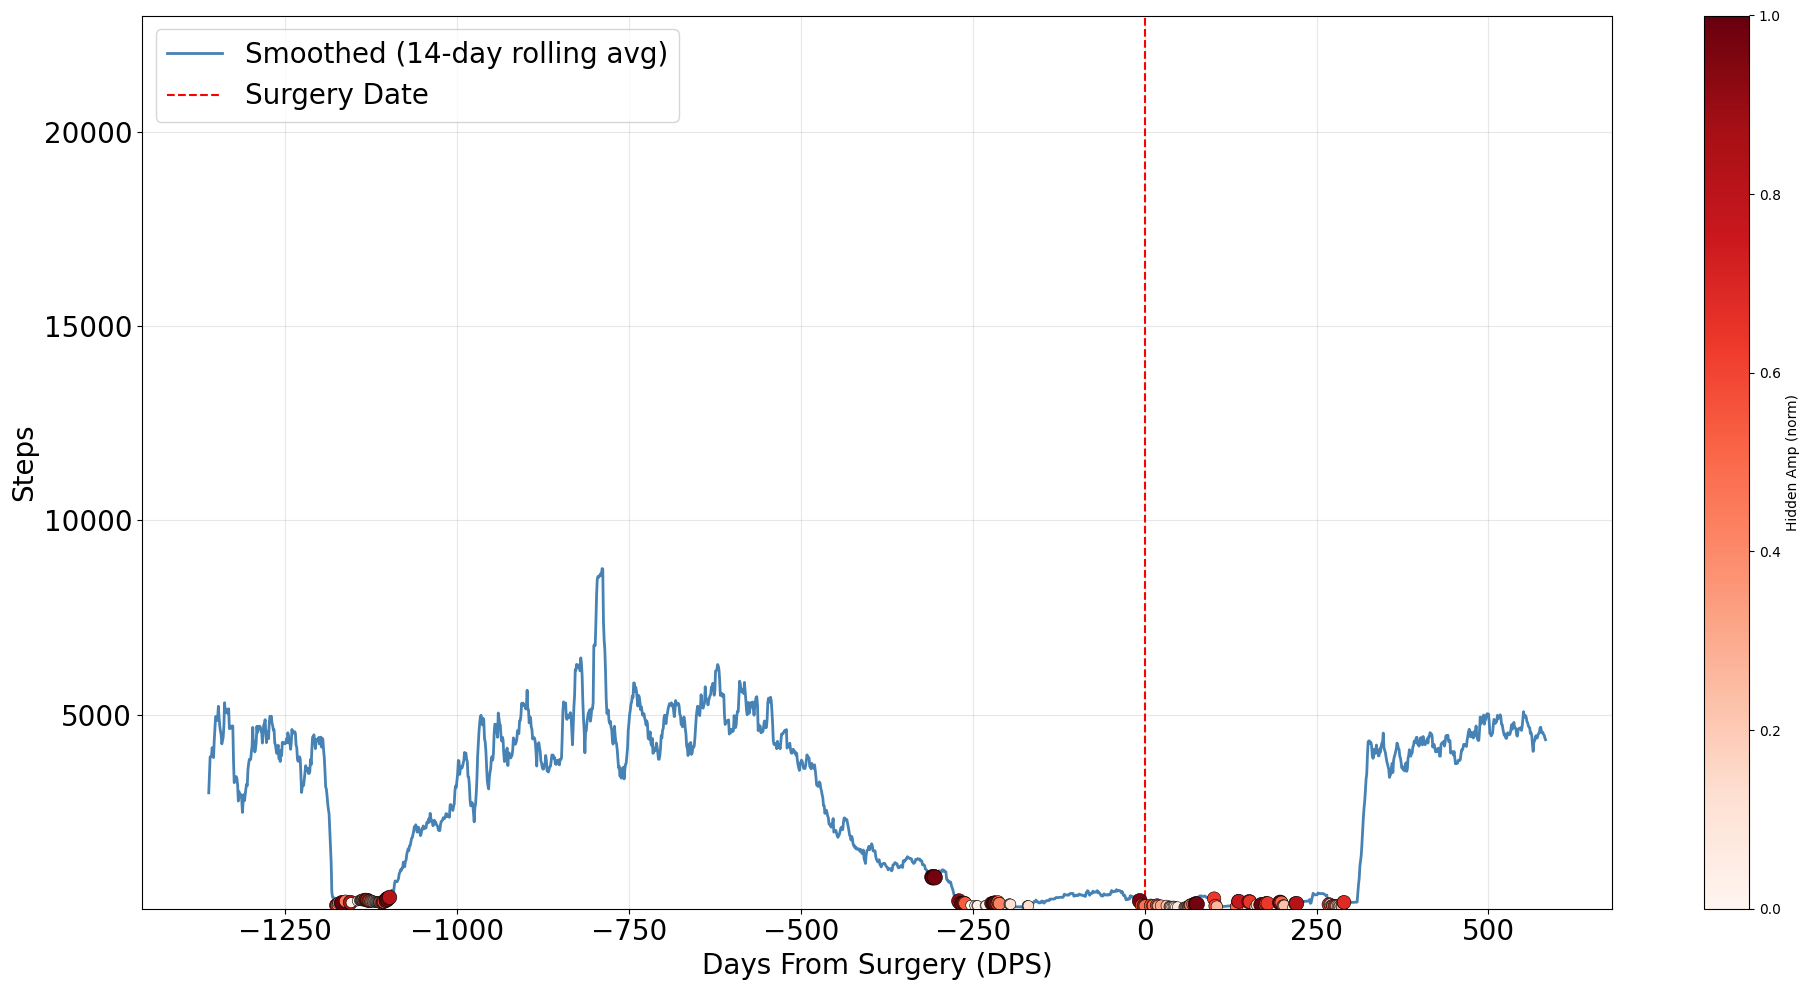

In [ ]:
file_path = "/content/gdrive/MyDrive/Colab Notebooks/UPenn/dataset/Analysis_Updated/PatientUSER-"+username+".xlsx"

window_days = 14            # smoothing window (days)
amp_smooth_window = 7       # smoothing for amplitude measure
amplitude_metric = 'absdiff' # 'absdiff' or 'rollstd'
morph_enable = False         # whether to draw morphed curve (set False to skip)
morph_strength = 0.10       # fraction of y-range for max displacement when morph enabled

# Hidden marker tuning (we aim to show "hidden but real" small peaks)
hidden_pct_low = 0.05      # lower quantile of amplitude to consider (e.g., 25%)

hidden_pct_high = 0.15     # upper quantile (e.g., 75%)
exclude_outlier_pct = 0.95 # amplitudes above this quantile considered obvious (exclude)
post_only = False           # only show hidden markers for post-op (DPS >= 0) if True

# marker visual mapping
marker_base_size = 5
marker_max_extra = 7

# ---------------- Data loading / fallback demo ----------------
if os.path.exists(file_path):
    df = pd.read_excel(file_path)
    df['Date'] = pd.to_datetime(df.get('Date', None), dayfirst=True, errors='coerce')
else:
    # demo synthetic dataset for testing
    rng = np.arange(-200, 361)
    baseline = 4000 + 200*np.sin(rng*0.02) + 200*np.cos(rng*0.005)
    surgery_effect = np.where(rng>=0, -900 * np.exp(-rng/50.0), 0)
    # hidden small bumps post-op
    hidden_bumps = np.zeros_like(rng, dtype=float)
    for center in [10, 30, 60, 120]:
        hidden_bumps += np.where((rng>=center-2)&(rng<=center+2), 400*np.exp(-(rng-center)**2/6), 0)
    steps = (baseline + surgery_effect + hidden_bumps + np.random.normal(scale=180, size=len(rng))).clip(min=0)
    df = pd.DataFrame({
        'Date': pd.to_datetime('2025-01-01') + pd.to_timedelta(rng, unit='D'),
        'Operation': ['Post Op DAY {}'.format(int(d)) if d>=0 else 'Pre Op DAY {}'.format(int(-d)) for d in rng],
        'Steps': steps
    })

# ---------------- DPS extraction ----------------
def extract_dps(op):
    try:
        s = str(op)
    except Exception:
        return np.nan
    m = re.search(r'(Pre|Post)\s*Op\s*DAY\s*(\d+)', s, re.IGNORECASE)
    if m:
        day = int(m.group(2))
        return -day if re.search(r'Pre', m.group(1), re.IGNORECASE) else day
    # fallback if column contains direct numeric day
    m2 = re.search(r'(-?\d+)', s)
    if m2:
        return int(m2.group(1))
    return np.nan

if 'DPS' not in df.columns:
    df['DPS'] = df.get('Operation', '').apply(extract_dps)

# sort and ensure numeric steps
df = df.sort_values('DPS').reset_index(drop=True)
df['Steps'] = pd.to_numeric(df['Steps'], errors='coerce').fillna(0)

# ---------------- smoothing and amplitude ----------------
df['Smoothed_Steps'] = df['Steps'].rolling(window=window_days, min_periods=1, center=True).mean()

if amplitude_metric == 'absdiff':
    df['Amplitude'] = (df['Steps'] - df['Smoothed_Steps']).abs()
elif amplitude_metric == 'rollstd':
    df['Amplitude'] = df['Steps'].rolling(window=window_days, min_periods=1, center=True).std().fillna(0)
else:
    raise ValueError("amplitude_metric must be 'absdiff' or 'rollstd'")

# smooth amplitude to avoid extremely jittery markers
df['Amplitude_Smooth'] = df['Amplitude'].rolling(window=amp_smooth_window, min_periods=1, center=True).mean()

# normalized amplitude (for marker mapping)
amp_vals = df['Amplitude_Smooth'].to_numpy(dtype=float)
if np.nanmax(amp_vals) - np.nanmin(amp_vals) < 1e-9:
    amp_norm = np.zeros_like(amp_vals)
else:
    amp_norm = (amp_vals - np.nanmin(amp_vals)) / (np.nanmax(amp_vals) - np.nanmin(amp_vals))
df['Amp_Norm'] = amp_norm

# ---------------- identify "hidden" amplitudes to mark ----------------
low_thr = df['Amplitude_Smooth'].quantile(hidden_pct_low)
high_thr = df['Amplitude_Smooth'].quantile(hidden_pct_high)
outlier_thr = df['Amplitude_Smooth'].quantile(exclude_outlier_pct)

# mask for candidates: within [low_thr, high_thr] and below outlier_thr
mask_hidden = (df['Amplitude_Smooth'] >= low_thr) & (df['Amplitude_Smooth'] <= high_thr) & (df['Amplitude_Smooth'] <= outlier_thr)

# optionally limit to post-op only (DPS >= 0)
if post_only:
    mask_hidden = mask_hidden & (df['DPS'] >= 0)

# Optionally also restrict to regions where smoothed curve looks "flat":
# define local slope magnitude and only keep hidden markers where slope is small
# (this enforces 'seemingly flat' selection)
slope = np.gradient(df['Smoothed_Steps'].to_numpy(), df['DPS'].to_numpy())
slope_abs = np.abs(slope)
slope_q = np.nanpercentile(slope_abs, 60)  # adaptivity; change percentile as needed
flat_mask = slope_abs <= slope_q
mask_hidden = mask_hidden & flat_mask

# prepare marker sizes and colors
hidden_amp_vals = df.loc[mask_hidden, 'Amplitude_Smooth'].to_numpy()
if len(hidden_amp_vals) > 0:
    # normalized for selected mask (so sizes are visible)
    hv = hidden_amp_vals
    hv_norm = (hv - hv.min()) / (hv.max() - hv.min() + 1e-9)
    sizes = marker_base_size + hv_norm * marker_max_extra
    colors = hv_norm  # use normalized amplitude for color scale mapping
else:
    sizes = np.array([])
    colors = np.array([])

# ---------------- optional Local Shape Morphing (normal offset) ----------------
x = df['DPS'].to_numpy(dtype=float)
y = df['Smoothed_Steps'].to_numpy(dtype=float)
ym_smooth = None
if morph_enable:
    # avoid duplicate x issues
    if np.any(np.diff(x) == 0):
        jitter = np.linspace(0, 1e-6, len(x))
        x = x + jitter
    dx = np.gradient(x)
    dy = np.gradient(y)
    tlen = np.sqrt(dx**2 + dy**2)
    tlen[tlen == 0] = 1e-9
    tx = dx / tlen
    ty = dy / tlen
    nx = -ty
    ny = tx
    y_range = np.nanmax(y) - np.nanmin(y)
    if y_range == 0:
        y_range = 1.0
    offset = df['Amp_Norm'].to_numpy() * morph_strength * y_range
    ym = y + ny * offset
    # light smoothing of morphed curve
    ym_smooth = pd.Series(ym).rolling(window=5, min_periods=1, center=True).mean().to_numpy()

# ---------------- Smoothing ----------------
window_days = 14
df['Smoothed_Steps'] = df['Steps'].rolling(
    window=window_days,
    min_periods=1,
    center=True
).mean()

plt.figure(figsize=(20, 10))

# 2️⃣ Smoothed Trend
plt.plot(
    df['DPS'],
    df['Smoothed_Steps'],
    color='steelblue',
    linewidth=2,
    label='Smoothed (14-day rolling avg)',
    zorder=2
)

# 3️⃣ Hidden Markers
if mask_hidden.any():
    sc = plt.scatter(
        df.loc[mask_hidden, 'DPS'],
        df.loc[mask_hidden, 'Smoothed_Steps'],
        s=sizes * 10,
        c=colors,
        cmap='Reds',
        edgecolors='black',
        linewidths=0.4,
        zorder=3
    )
    cbar = plt.colorbar(sc)
    cbar.set_label('Hidden Amp (norm)')

# 4️⃣ Surgery Line
plt.axvline(
    x=0,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Surgery Date',
    zorder=2
)


y_min = df['Steps'].min()
y_max = df['Steps'].max()
plt.ylim(y_min, y_max)


plt.xlabel("Days From Surgery (DPS)", fontsize=20)
plt.ylabel("Steps", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Using datetime column: Datetime
             Datetime   AEP_MW
0 2004-12-31 01:00:00  13478.0
1 2004-12-31 02:00:00  12865.0
2 2004-12-31 03:00:00  12577.0
Using value column: AEP_MW


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1245: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1246: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1247: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1253: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]


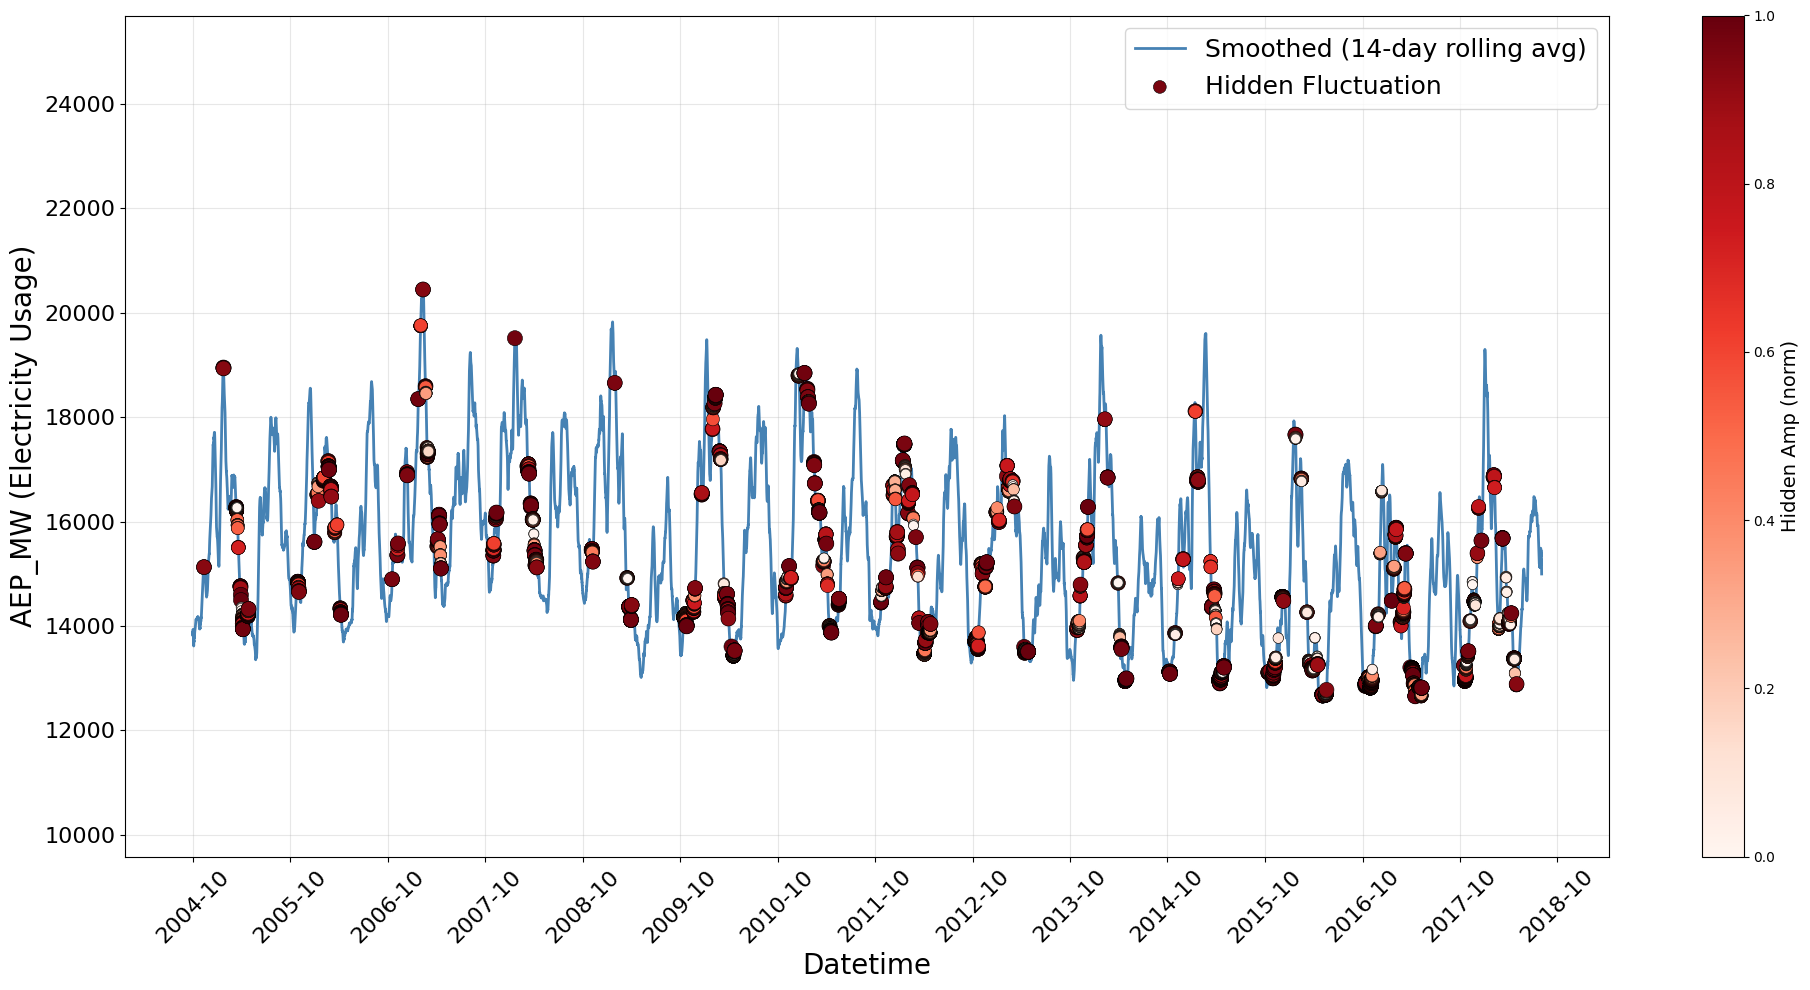

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

file_path = "/content/gdrive/MyDrive/Colab Notebooks/UPenn/dataset/Public Dataset/AEP_hourly.csv"

window_hours     = 24 * 14
amp_smooth_window = 24 * 7
amplitude_metric  = 'absdiff'   # 'absdiff' 或 'rollstd'

# Hidden marker
hidden_pct_low      = 0.05
hidden_pct_high     = 0.15
exclude_outlier_pct = 0.95
post_only           = False

marker_base_size = 5
marker_max_extra = 7

df_raw = pd.read_csv(file_path)

if 'Datetime' in df_raw.columns:
    dt_col = 'Datetime'
else:
    cand = [c for c in df_raw.columns if 'date' in c.lower() or 'time' in c.lower()]
    dt_col = cand[0] if cand else df_raw.columns[0]

df_raw[dt_col] = pd.to_datetime(df_raw[dt_col], errors='coerce')
print(f"Using datetime column: {dt_col}")
print(df_raw.head(3))

value_candidates = [c for c in df_raw.columns if c != dt_col and pd.api.types.is_numeric_dtype(df_raw[c])]
if len(value_candidates) == 0:

    value_candidates = [c for c in df_raw.columns if c != dt_col]
val_col = value_candidates[0]
print(f"Using value column: {val_col}")

df = df_raw[[dt_col, val_col]].copy()
df.columns = ['Datetime', 'Steps']
df['Steps'] = pd.to_numeric(df['Steps'], errors='coerce').fillna(0)
df = df.sort_values('Datetime').reset_index(drop=True)

df['Smoothed_Steps'] = df['Steps'].rolling(window=window_hours, min_periods=1, center=True).mean()

if amplitude_metric == 'absdiff':
    df['Amplitude'] = (df['Steps'] - df['Smoothed_Steps']).abs()
elif amplitude_metric == 'rollstd':
    df['Amplitude'] = df['Steps'].rolling(window=window_hours, min_periods=1, center=True).std().fillna(0)
else:
    raise ValueError("amplitude_metric must be 'absdiff' or 'rollstd'")

df['Amplitude_Smooth'] = df['Amplitude'].rolling(window=amp_smooth_window, min_periods=1, center=True).mean()

amp_vals = df['Amplitude_Smooth'].to_numpy(dtype=float)
if np.nanmax(amp_vals) - np.nanmin(amp_vals) < 1e-9:
    amp_norm = np.zeros_like(amp_vals)
else:
    amp_norm = (amp_vals - np.nanmin(amp_vals)) / (np.nanmax(amp_vals) - np.nanmin(amp_vals))
df['Amp_Norm'] = amp_norm

low_thr     = df['Amplitude_Smooth'].quantile(hidden_pct_low)
high_thr    = df['Amplitude_Smooth'].quantile(hidden_pct_high)
outlier_thr = df['Amplitude_Smooth'].quantile(exclude_outlier_pct)

mask_hidden = (
    (df['Amplitude_Smooth'] >= low_thr) &
    (df['Amplitude_Smooth'] <= high_thr) &
    (df['Amplitude_Smooth'] <= outlier_thr)
)

x_numeric = (df['Datetime'] - df['Datetime'].iloc[0]).dt.total_seconds().to_numpy()
slope     = np.gradient(df['Smoothed_Steps'].to_numpy(), x_numeric)
slope_abs = np.abs(slope)
slope_q   = np.nanpercentile(slope_abs, 60)
flat_mask = slope_abs <= slope_q

mask_hidden = mask_hidden & flat_mask

hidden_amp_vals = df.loc[mask_hidden, 'Amplitude_Smooth'].to_numpy()
if len(hidden_amp_vals) > 0:
    hv_norm = (hidden_amp_vals - hidden_amp_vals.min()) / (hidden_amp_vals.max() - hidden_amp_vals.min() + 1e-9)
    sizes  = marker_base_size + hv_norm * marker_max_extra
    colors = hv_norm
else:
    sizes  = np.array([])
    colors = np.array([])

fig, ax = plt.subplots(figsize=(20, 10))

ax.plot(
    df['Datetime'],
    df['Smoothed_Steps'],
    color='steelblue',
    linewidth=2,
    label=f'Smoothed ({window_hours//24}-day rolling avg)',
    zorder=2
)

# Hidden markers
if mask_hidden.any():
    sc = ax.scatter(
        df.loc[mask_hidden, 'Datetime'],
        df.loc[mask_hidden, 'Smoothed_Steps'],
        s=sizes * 10,
        c=colors,
        cmap='Reds',
        edgecolors='black',
        linewidths=0.4,
        zorder=3,
        label='Hidden Fluctuation'
    )
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Hidden Amp (norm)', fontsize=14)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, fontsize=16)

y_min = df['Steps'].min()
y_max = df['Steps'].max()
ax.set_ylim(y_min, y_max)

ax.set_xlabel("Datetime", fontsize=20)
ax.set_ylabel("AEP_MW (Electricity Usage)", fontsize=20)
ax.yticks = plt.yticks(fontsize=16)
ax.legend(fontsize=18)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

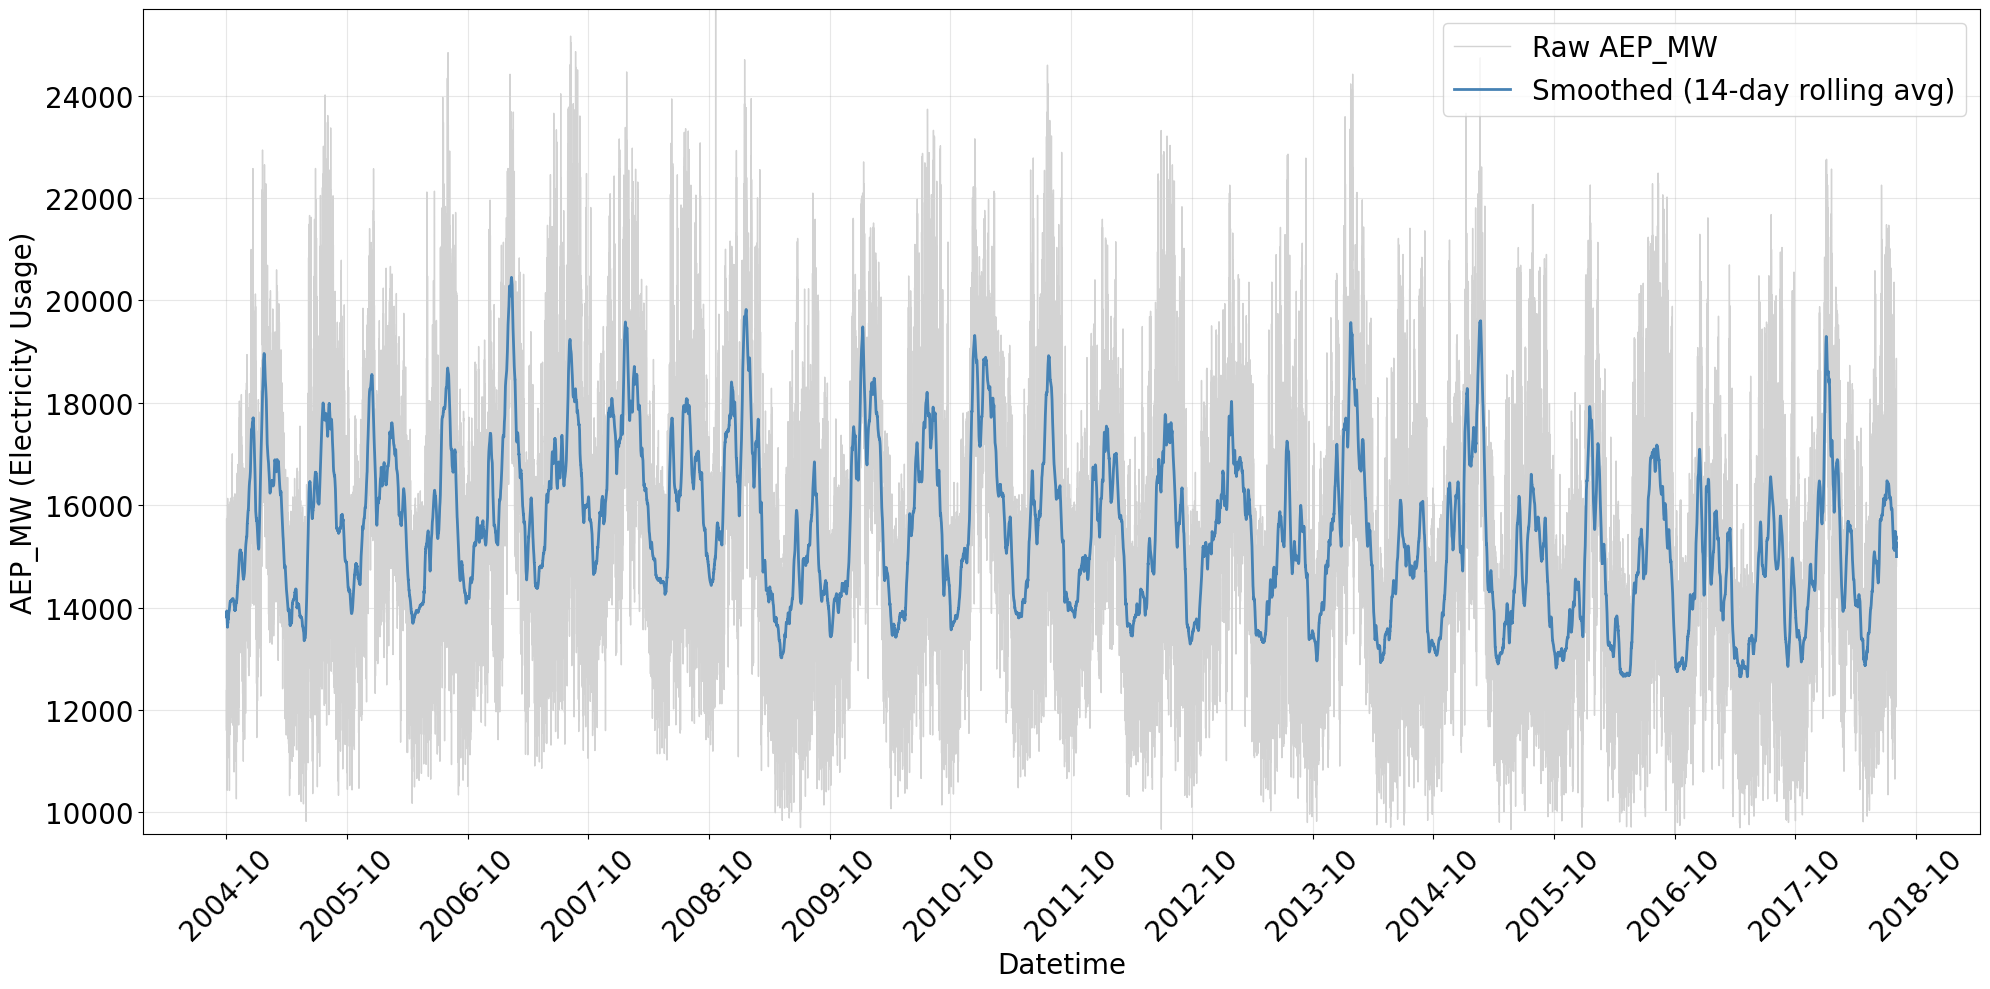

In [ ]:
window_hours = 24 * 14

df['Smoothed_Steps'] = df['Steps'].rolling(window=window_hours, min_periods=1, center=True).mean()

plt.figure(figsize=(20, 10))

plt.plot(df['Datetime'], df['Steps'], color='lightgray', linewidth=1, label='Raw AEP_MW')
plt.plot(df['Datetime'], df['Smoothed_Steps'], color='steelblue', linewidth=2, label='Smoothed (14-day rolling avg)')

y_min = df['Steps'].min()
y_max = df['Steps'].max()
plt.ylim(y_min, y_max)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=12))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, fontsize=20)
plt.yticks(fontsize=20)

plt.xlabel("Datetime", fontsize=20)
plt.ylabel("AEP_MW (Electricity Usage)", fontsize=20)
plt.legend(fontsize=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()